In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import utils

utils.set_matplotlib_style()

## Teacher–Student Gap vs Student Degradation

In [2]:
olympiads_accuracies = {
    'qwen4b': 0.57,
    'qwen30b': 0.62,
    'qwen235b': 0.59, 
    'llama8b': 0.05,
    'llama70b': 0.2,
    'deepseek': 0.61,
    'gpt_4.1_nano': 0.295,
    'claude_haiku_4.5': 0.55, 
    'gemma_4_26b_a4b_it': 0.54,
    'claude_opus_4.7': 0.815,
    'gpt_5.5': 0.775,
}

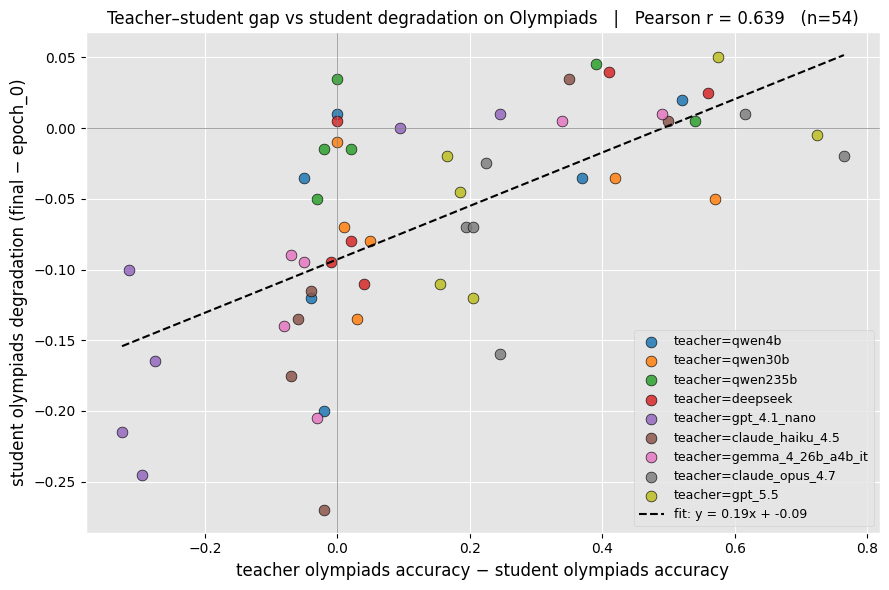

In [9]:
SWEEP_RUN_DIR = Path('/workspace/when-does-sft-degrade-capabilities/runs/sweep_1')
STUDENTS = ['qwen4b', 'qwen30b', 'qwen235b', 'llama8b', 'llama70b', 'deepseek']

# TEACHERS = ['qwen4b', 'qwen30b', 'qwen235b', 'llama8b', 'llama70b', 'deepseek',
#             'gpt_4.1_nano', 'claude_haiku_4.5', 'gemma_4_26b_a4b_it', 'claude_opus_4.7', 'gpt_5.5']

TEACHERS = ['qwen4b', 'qwen30b', 'qwen235b', 'deepseek',
            'gpt_4.1_nano', 'claude_haiku_4.5', 'gemma_4_26b_a4b_it', 'claude_opus_4.7', 'gpt_5.5']


def olympiads_degradation(student, teacher):
    path = SWEEP_RUN_DIR / f'student_{student}_teacher_{teacher}' / 'metadata.json'
    if not path.exists():
        return np.nan
    scores = json.loads(path.read_text())['olympiads']
    return scores[-1] - scores[0]


xs, ys, teachers_for_point = [], [], []
for student in STUDENTS:
    for teacher in TEACHERS:
        # if student == teacher:
        #     continue
        deg = olympiads_degradation(student, teacher)
        if np.isnan(deg):
            continue
        xs.append(olympiads_accuracies[teacher] - olympiads_accuracies[student])
        ys.append(deg)
        teachers_for_point.append(teacher)

xs = np.array(xs)
ys = np.array(ys)

r = np.corrcoef(xs, ys)[0, 1]
slope, intercept = np.polyfit(xs, ys, 1)

fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.get_cmap('tab10' if len(TEACHERS) <= 10 else 'tab20')
for k, t in enumerate(TEACHERS):
    sel = [i for i, tp in enumerate(teachers_for_point) if tp == t]
    if not sel:
        continue
    ax.scatter(xs[sel], ys[sel], color=cmap(k % cmap.N), label=f'teacher={t}',
               alpha=0.85, edgecolor='black', linewidth=0.5, s=60)

line_x = np.array([xs.min(), xs.max()])
ax.plot(line_x, slope * line_x + intercept, color='black', linestyle='--',
        label=f'fit: y = {slope:.2f}x + {intercept:+.2f}')

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('teacher olympiads accuracy − student olympiads accuracy')
ax.set_ylabel('student olympiads degradation (final − epoch_0)')
ax.set_title(f'Teacher–student gap vs student degradation on Olympiads   |   '
             f'Pearson r = {r:.3f}   (n={len(xs)})')
ax.legend(loc='best', fontsize=9)
fig.tight_layout()
plt.show()

## BoN

In [2]:
import tinker
from pathlib import Path

from evals.olympiads import load_olympiads_dataset, format_olympiads_chat
from utils import GenerateConfig, generate_async

# --- Config ---
service_client = tinker.ServiceClient()
sampling_client = service_client.create_sampling_client(model_path = 'tinker://2da0d66a-4f62-53ca-b6d3-dd7068972c45:train:0/sampler_weights/student_llama70b_teacher_llama8b_step_100')
# sampling_client = service_client.create_sampling_client(base_model = 'Qwen/Qwen3-30B-A3B-Instruct-2507')
SPLIT = 'val'
STARTING_PROBLEM = 0
NUM_PROBLEMS = 200
NUM_SAMPLES = 64
TEMPERATURE = 1.0
MAX_TOKENS = 10000

system_prompt = Path('prompts/benign_system_prompt.txt').read_text()
olympiads_prompt = Path('prompts/olympiads_prompt.txt').read_text()

# --- Load + format ---
ds = load_olympiads_dataset(split=SPLIT)[STARTING_PROBLEM:STARTING_PROBLEM + NUM_PROBLEMS]
messages_list = format_olympiads_chat(ds, system_prompt, olympiads_prompt)

# --- Generate (num_samples completions per problem) ---
config = GenerateConfig(
    temperature=TEMPERATURE,
    max_tokens=MAX_TOKENS,
    num_samples=NUM_SAMPLES,
    max_concurrent = 2000,
    cache = False
)
outputs = await generate_async(
    sampling_client=sampling_client,
    messages_list=messages_list,
    config=config,
    add_generation_prompt=True,
)

# --- Score: extract <answer>...</answer> from each sample ---
def extract_answer(response: str) -> str:
    if '<answer>' in response:
        return response.split('<answer>')[-1].split('</answer>')[0].strip()
    return ''

correct = np.zeros((len(ds), NUM_SAMPLES), dtype=bool)
for i, (problem, output_dict) in enumerate(zip(ds, outputs)):
    expected = problem['answer'].strip()
    samples = output_dict['output']  # list of NUM_SAMPLES strings
    for j, response in enumerate(samples):
        correct[i, j] = (extract_answer(response) == expected)

print(f'correct shape: {correct.shape}')
print(f'mean accuracy across all samples: {correct.mean():.3f}')
print(f'pass@1 (mean per-sample): {correct.mean(axis=1).mean():.3f}')
print(f'pass@{NUM_SAMPLES} (any sample correct): {correct.any(axis=1).mean():.3f}')
json.dump(outputs, open('trained_llama_70b_olympiads_bo64.json', 'w'), indent = 4)

Your Tinker SDK version is outdated. Please upgrade to the latest version.


Loading val split of Olympiads dataset...
Beginning Tokenization...


Tokenizing: 100%|██████████| 200/200 [00:00<00:00, 906.44it/s]


Cache: 0/200 hits, generating 200 new (2000 concurrent requests)
Starting generation...
Finished tokenization, starting generation...


Generating: 100%|██████████| 200/200 [10:35<00:00,  3.18s/it] 


correct shape: (200, 64)
mean accuracy across all samples: 0.102
pass@1 (mean per-sample): 0.102
pass@64 (any sample correct): 0.550


In [3]:
import tinker
from pathlib import Path

from evals.olympiads import load_olympiads_dataset, format_olympiads_chat
from utils import GenerateConfig, generate_async

# --- Config ---
service_client = tinker.ServiceClient()
# sampling_client = service_client.create_sampling_client(model_path = 'tinker://e8a0e135-6302-51be-b5ad-54aae066a5a6:train:0/sampler_weights/student_qwen4b_teacher_llama8b_step_100')
sampling_client = service_client.create_sampling_client(base_model = 'meta-llama/Llama-3.3-70B-Instruct')
SPLIT = 'val'
STARTING_PROBLEM = 0
NUM_PROBLEMS = 200
NUM_SAMPLES = 64
TEMPERATURE = 1.0
MAX_TOKENS = 10000

system_prompt = Path('prompts/benign_system_prompt.txt').read_text()
olympiads_prompt = Path('prompts/olympiads_prompt.txt').read_text()

# --- Load + format ---
ds = load_olympiads_dataset(split=SPLIT)[STARTING_PROBLEM:STARTING_PROBLEM + NUM_PROBLEMS]
messages_list = format_olympiads_chat(ds, system_prompt, olympiads_prompt)

# --- Generate (num_samples completions per problem) ---
config = GenerateConfig(
    temperature=TEMPERATURE,
    max_tokens=MAX_TOKENS,
    num_samples=NUM_SAMPLES,
    max_concurrent = 2000,
    cache = False
)
outputs = await generate_async(
    sampling_client=sampling_client,
    messages_list=messages_list,
    config=config,
    add_generation_prompt=True,
)

# --- Score: extract <answer>...</answer> from each sample ---
def extract_answer(response: str) -> str:
    if '<answer>' in response:
        return response.split('<answer>')[-1].split('</answer>')[0].strip()
    return ''

correct = np.zeros((len(ds), NUM_SAMPLES), dtype=bool)
for i, (problem, output_dict) in enumerate(zip(ds, outputs)):
    expected = problem['answer'].strip()
    samples = output_dict['output']  # list of NUM_SAMPLES strings
    for j, response in enumerate(samples):
        correct[i, j] = (extract_answer(response) == expected)

print(f'correct shape: {correct.shape}')
print(f'mean accuracy across all samples: {correct.mean():.3f}')
print(f'pass@1 (mean per-sample): {correct.mean(axis=1).mean():.3f}')
print(f'pass@{NUM_SAMPLES} (any sample correct): {correct.any(axis=1).mean():.3f}')
json.dump(outputs, open('base_llama_70b_olympiads_bo64.json', 'w'), indent = 4)

Your Tinker SDK version is outdated. Please upgrade to the latest version.


Loading val split of Olympiads dataset...
Beginning Tokenization...


Tokenizing: 100%|██████████| 200/200 [00:00<00:00, 1211.94it/s]

Cache: 0/200 hits, generating 200 new (2000 concurrent requests)
Starting generation...


Finished tokenization, starting generation...


Generating:   0%|          | 0/200 [00:00<?, ?it/s]

Generating: 100%|██████████| 200/200 [10:41<00:00,  3.21s/it]


correct shape: (200, 64)
mean accuracy across all samples: 0.186
pass@1 (mean per-sample): 0.186
pass@64 (any sample correct): 0.495


Loading val split of Olympiads dataset...
0
['Llama-8B', 'Qwen-4B trained on Llama-8B', 'Base Qwen-4B']
1
['Llama-8B', 'Qwen-4B trained on Llama-8B', 'Base Qwen-4B']
2
['Llama-8B', 'Qwen-4B trained on Llama-8B', 'Base Qwen-4B']


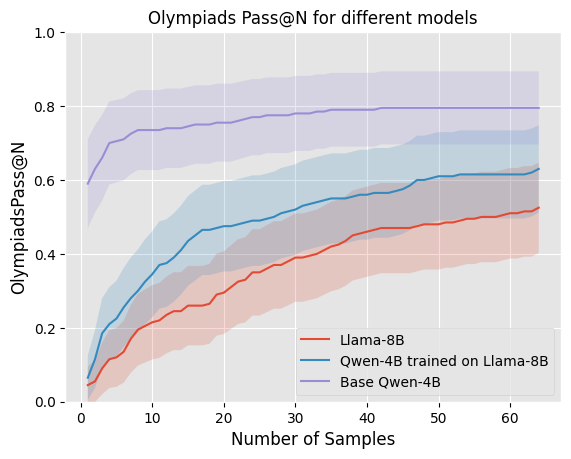

In [8]:
from evals.olympiads import load_olympiads_dataset
ds = load_olympiads_dataset(split='val')[:200]
NUM_SAMPLES = 64

# # Llama 70B
# output_paths = [
#     '/workspace/when-does-sft-degrade-capabilities/runs/bon/llama_olympiads_bo64.json',
#     '/workspace/when-does-sft-degrade-capabilities/runs/bon/bon_llama_70b/trained_llama_70b_olympiads_bo64.json',
#     '/workspace/when-does-sft-degrade-capabilities/runs/bon/bon_llama_70b/base_llama_70b_olympiads_bo64.json'
# ]

# names = [
#     'Llama-8B',
#     'Llama-70B trained on Llama-8B',
#     'Base Llama-70B'
# ]

output_paths = [
    '/workspace/when-does-sft-degrade-capabilities/runs/bon/llama_olympiads_bo64.json',
    '/workspace/when-does-sft-degrade-capabilities/runs/bon/bon_qwen_4b/trained_qwen4b_olympiads_bo64.json',
    '/workspace/when-does-sft-degrade-capabilities/runs/bon/bon_qwen_4b/base_qwen4b_olympiads_bo64.json',
]

names = [
    'Llama-8B',
    'Qwen-4B trained on Llama-8B',
    'Base Qwen-4B'
]
ns = range(1, 65)

for k in range(len(output_paths)):
    print(k)
    print(names)
    outputs = json.load(open(output_paths[k]))
    # --- Score: extract <answer>...</answer> from each sample ---
    def extract_answer(response: str) -> str:
        if '<answer>' in response:
            return response.split('<answer>')[-1].split('</answer>')[0].strip()
        return ''

    correct = np.zeros((len(ds), NUM_SAMPLES), dtype=bool)
    for i, (problem, output_dict) in enumerate(zip(ds, outputs)):
        expected = problem['answer'].strip()
        samples = output_dict['output']  # list of NUM_SAMPLES strings
        for j, response in enumerate(samples):
            correct[i, j] = (extract_answer(response) == expected)

    probs = correct.mean(axis = -1)

    passes = []
    for n in range(1, correct.shape[1] + 1):
        passes.append(correct[:, :n].any(axis=1).mean())

    passes = np.array(passes)
    errs = 1.96 * np.sqrt(passes * (1 - passes) / NUM_SAMPLES)


    plt.plot(ns, passes, label = names[k])
    plt.fill_between(ns, passes - errs, passes + errs, alpha = 0.2)
    
plt.ylim(0, 1)
plt.legend()
plt.xlabel('Number of Samples')
plt.ylabel('OlympiadsPass@N')
plt.title('Olympiads Pass@N for different models')
plt.show()


## Sweep 1

In [2]:
RUN_DIR = Path('/workspace/when-does-sft-degrade-capabilities/runs/sweep_1')
STUDENTS = ['qwen4b', 'qwen30b', 'qwen235b', 'llama8b', 'llama70b', 'deepseek']
TEACHERS = ['qwen4b', 'qwen30b', 'qwen235b', 'llama8b', 'llama70b', 'deepseek', 'gpt_4.1_nano', 'claude_haiku_4.5', 'gemma_4_26b_a4b_it', 'claude_opus_4.7', 'gpt_5.5']
EVALS = ['ifeval', 'math_500', 'mmlu', 'olympiads']

### Math-500 Heatmaps by Level

Loaded 293/500 MATH-500 problems (integer answers only)


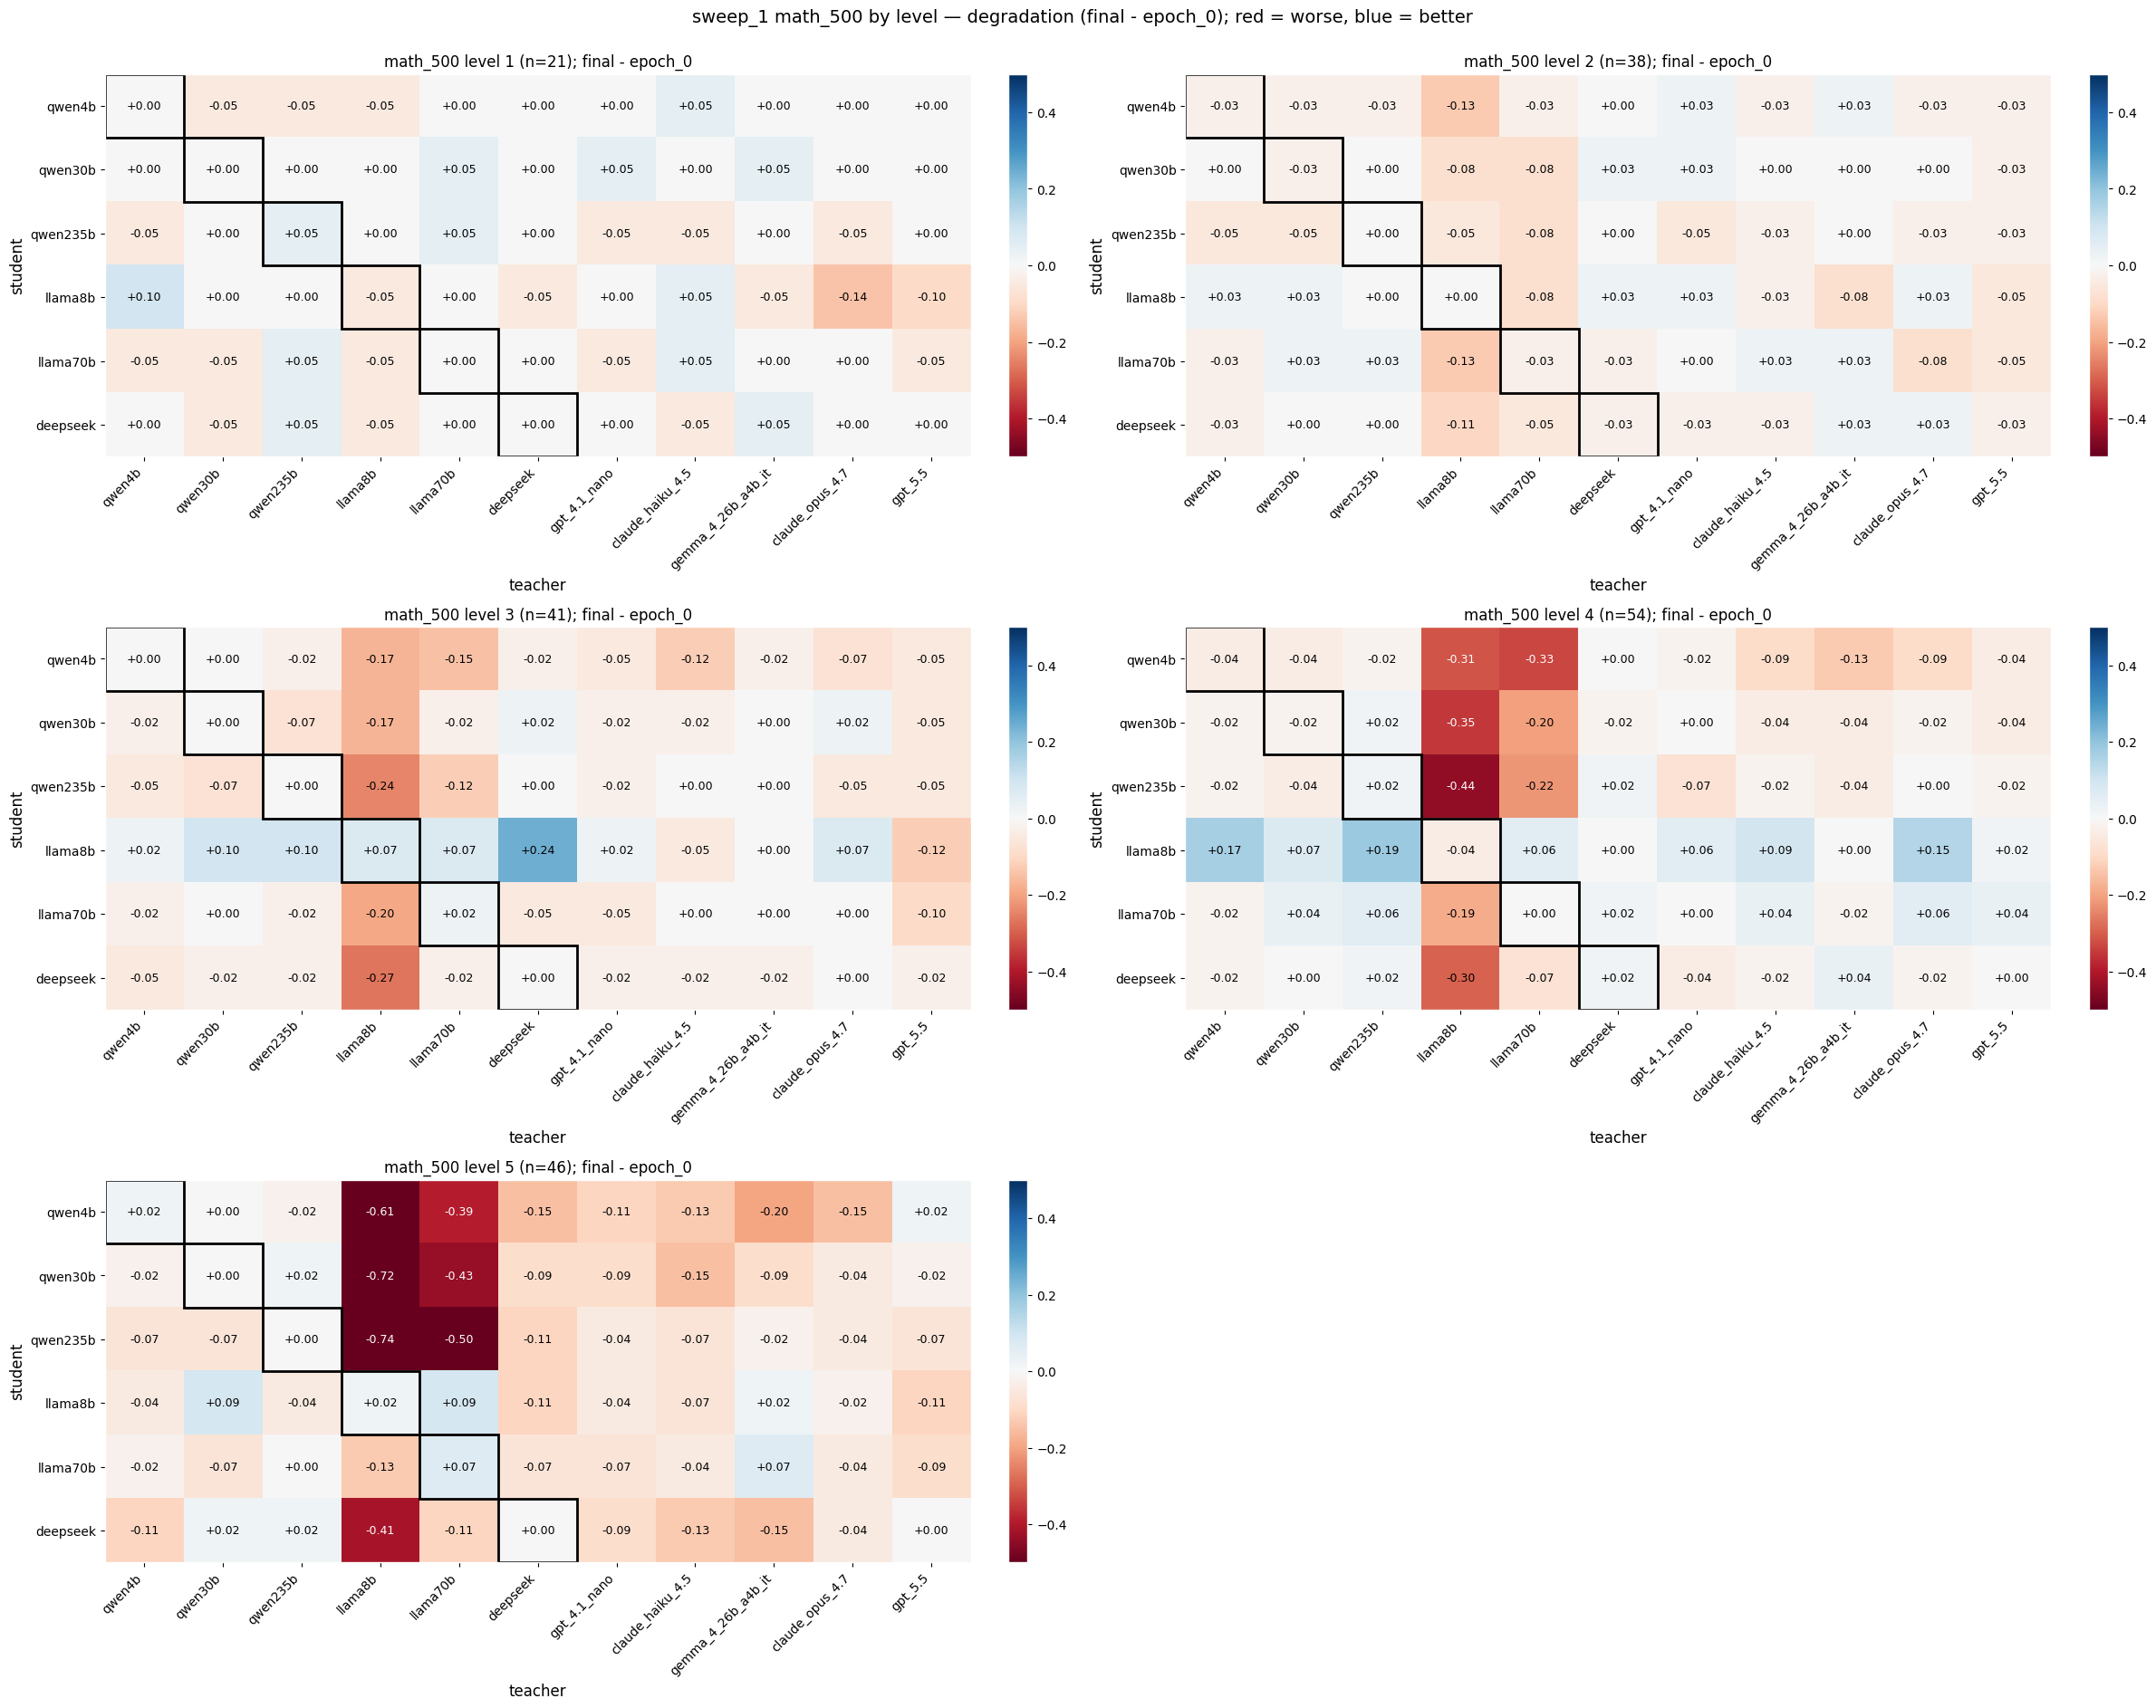

In [12]:
from matplotlib.patches import Rectangle

from evals.math_500 import load_math_500

# Load problems and their levels in dataset order; runs evaluate the first 200.
math500_problems = load_math_500(filter_integer=True)[:200]
math500_levels = np.array([p['level'] for p in math500_problems])
LEVELS = sorted(set(math500_levels.tolist()))


def _math500_log_step(path):
    """Sort key for log files: epoch_0 first, then by step number."""
    name = path.stem
    if name.endswith('_epoch_0'):
        return -1
    return int(name.rsplit('_step_', 1)[-1])


def _load_math500_correct(path):
    if not path.exists():
        return None
    return np.array([r['correct'] for r in json.loads(path.read_text())])


def load_math500_level_degradation(level, student, teacher):
    log_dir = RUN_DIR / f'student_{student}_teacher_{teacher}' / 'math_500'
    if not log_dir.exists():
        return np.nan
    files = sorted(log_dir.glob('math_500_*.json'), key=_math500_log_step)
    if len(files) < 2:
        return np.nan
    first = _load_math500_correct(files[0])
    last = _load_math500_correct(files[-1])
    if first is None or last is None:
        return np.nan
    mask = math500_levels == level
    return last[mask].mean() - first[mask].mean()


VLIM = 0.5
ncols = min(2, len(LEVELS))
nrows = int(np.ceil(len(LEVELS) / ncols))
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * (1 + 1.0 * len(TEACHERS)),
                                  nrows * (1 + 0.9 * len(STUDENTS))),
                         squeeze=False)
for ax, level in zip(axes.flat, LEVELS):
    grid = np.array([[load_math500_level_degradation(level, s, t) for t in TEACHERS] for s in STUDENTS])
    n_problems = int((math500_levels == level).sum())
    im = ax.imshow(grid, cmap='RdBu', vmin=-VLIM, vmax=VLIM, aspect='auto')
    ax.set_xticks(range(len(TEACHERS)), TEACHERS, rotation=45, ha='right')
    ax.set_yticks(range(len(STUDENTS)), STUDENTS)
    ax.set_xlabel('teacher')
    ax.set_ylabel('student')
    ax.set_title(f'math_500 level {level} (n={n_problems}); final - epoch_0')
    ax.grid(False)
    for i, student in enumerate(STUDENTS):
        for j, teacher in enumerate(TEACHERS):
            v = grid[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                        color='white' if abs(v) > 0.6 * VLIM else 'black', fontsize=9)
            if student == teacher:
                ax.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1,
                                       fill=False, edgecolor='black', linewidth=2))
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for ax in list(axes.flat)[len(LEVELS):]:
    ax.axis('off')

fig.suptitle('sweep_1 math_500 by level — degradation (final - epoch_0); red = worse, blue = better')
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### Plot Heatmaps

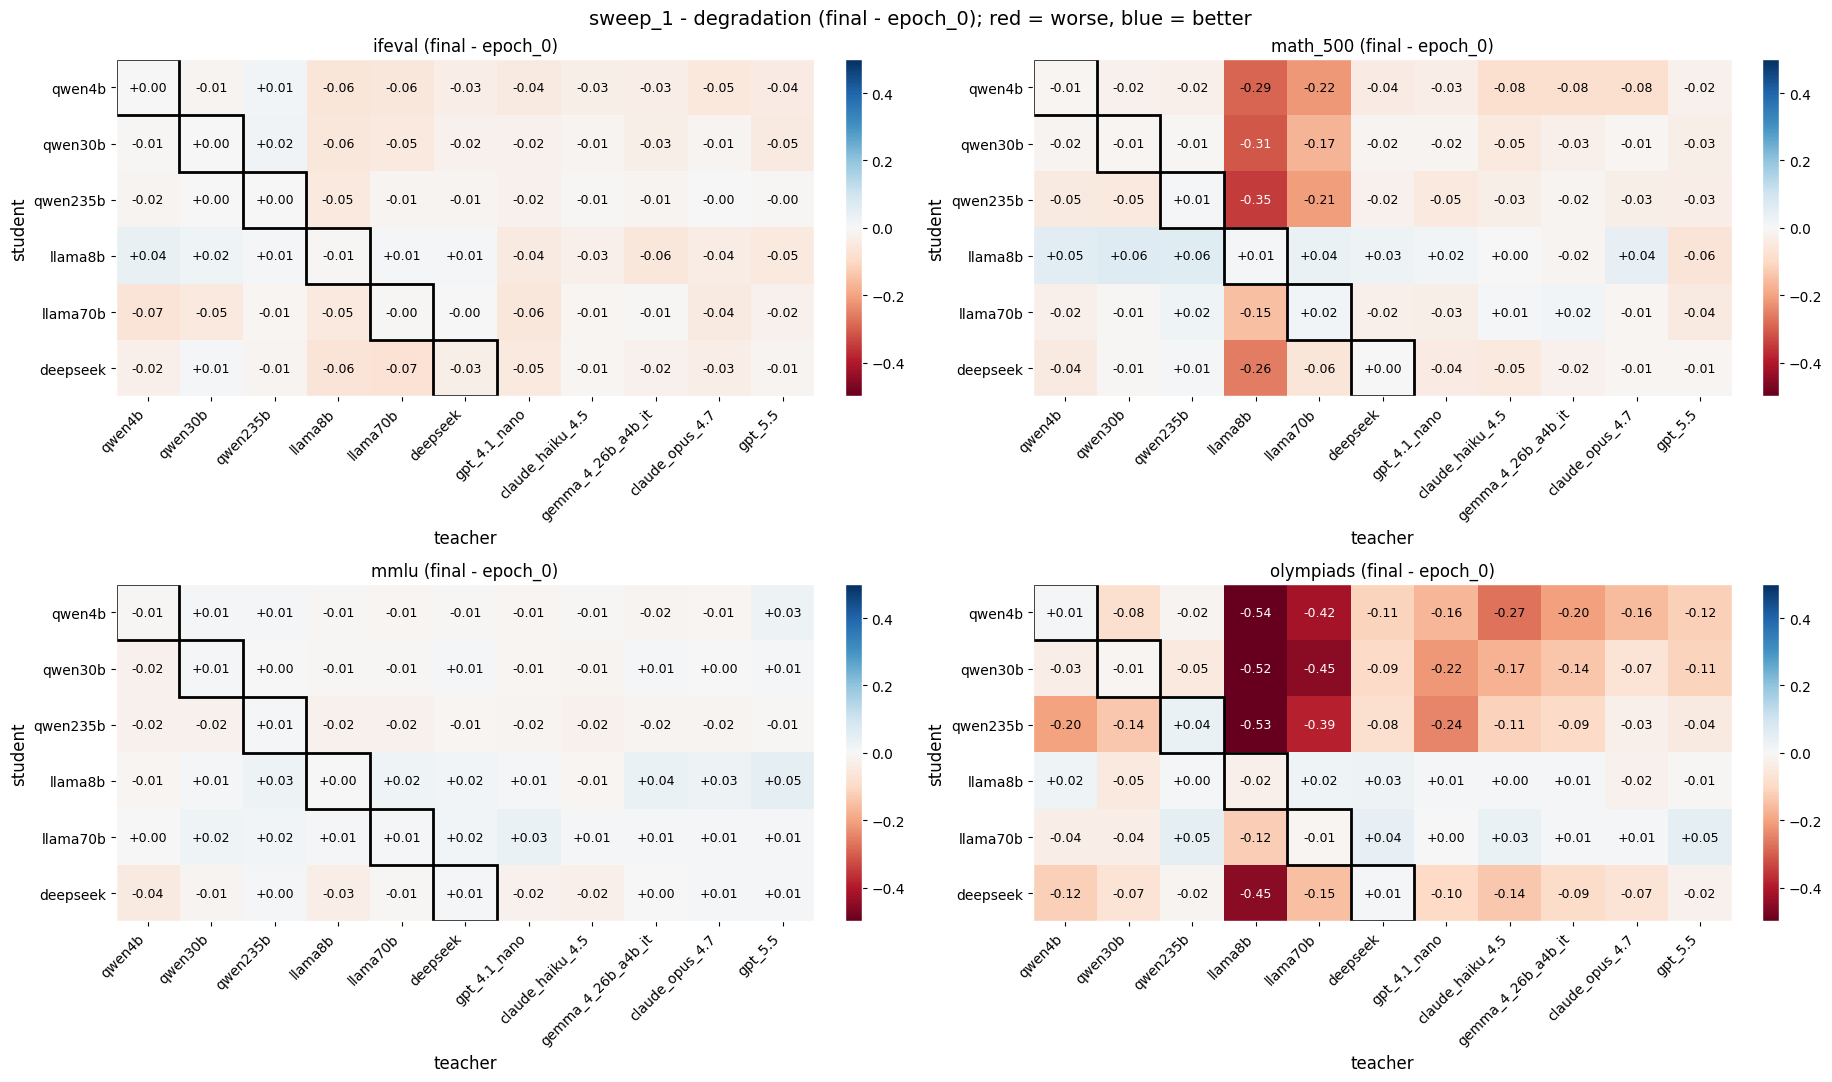

In [4]:
from matplotlib.patches import Rectangle

def load_degradation(eval_name, student, teacher):
    path = RUN_DIR / f'student_{student}_teacher_{teacher}' / 'metadata.json'
    if not path.exists():
        return np.nan
    scores = json.loads(path.read_text())[eval_name]
    return scores[-1] - scores[0]


VLIM = 0.5

fig, axes = plt.subplots(2, 2, figsize=(2 + 1.5 * len(TEACHERS), 2 + 1.5 * len(STUDENTS)))
for ax, eval_name in zip(axes.flat, EVALS):
    grid = np.array([[load_degradation(eval_name, s, t) for t in TEACHERS] for s in STUDENTS])
    im = ax.imshow(grid, cmap='RdBu', vmin=-VLIM, vmax=VLIM, aspect='auto')
    ax.set_xticks(range(len(TEACHERS)), TEACHERS, rotation=45, ha='right')
    ax.set_yticks(range(len(STUDENTS)), STUDENTS)
    ax.set_xlabel('teacher')
    ax.set_ylabel('student')
    ax.set_title(f'{eval_name} (final - epoch_0)')
    ax.grid(False)
    for i, student in enumerate(STUDENTS):
        for j, teacher in enumerate(TEACHERS):
            v = grid[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                        color='white' if abs(v) > 0.6 * VLIM else 'black', fontsize=9)
            if student == teacher:
                ax.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1,
                                       fill=False, edgecolor='black', linewidth=2))
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('sweep_1 - degradation (final - epoch_0); red = worse, blue = better')
fig.tight_layout()
plt.show()

### Loss Curves + Olympiads Degradation

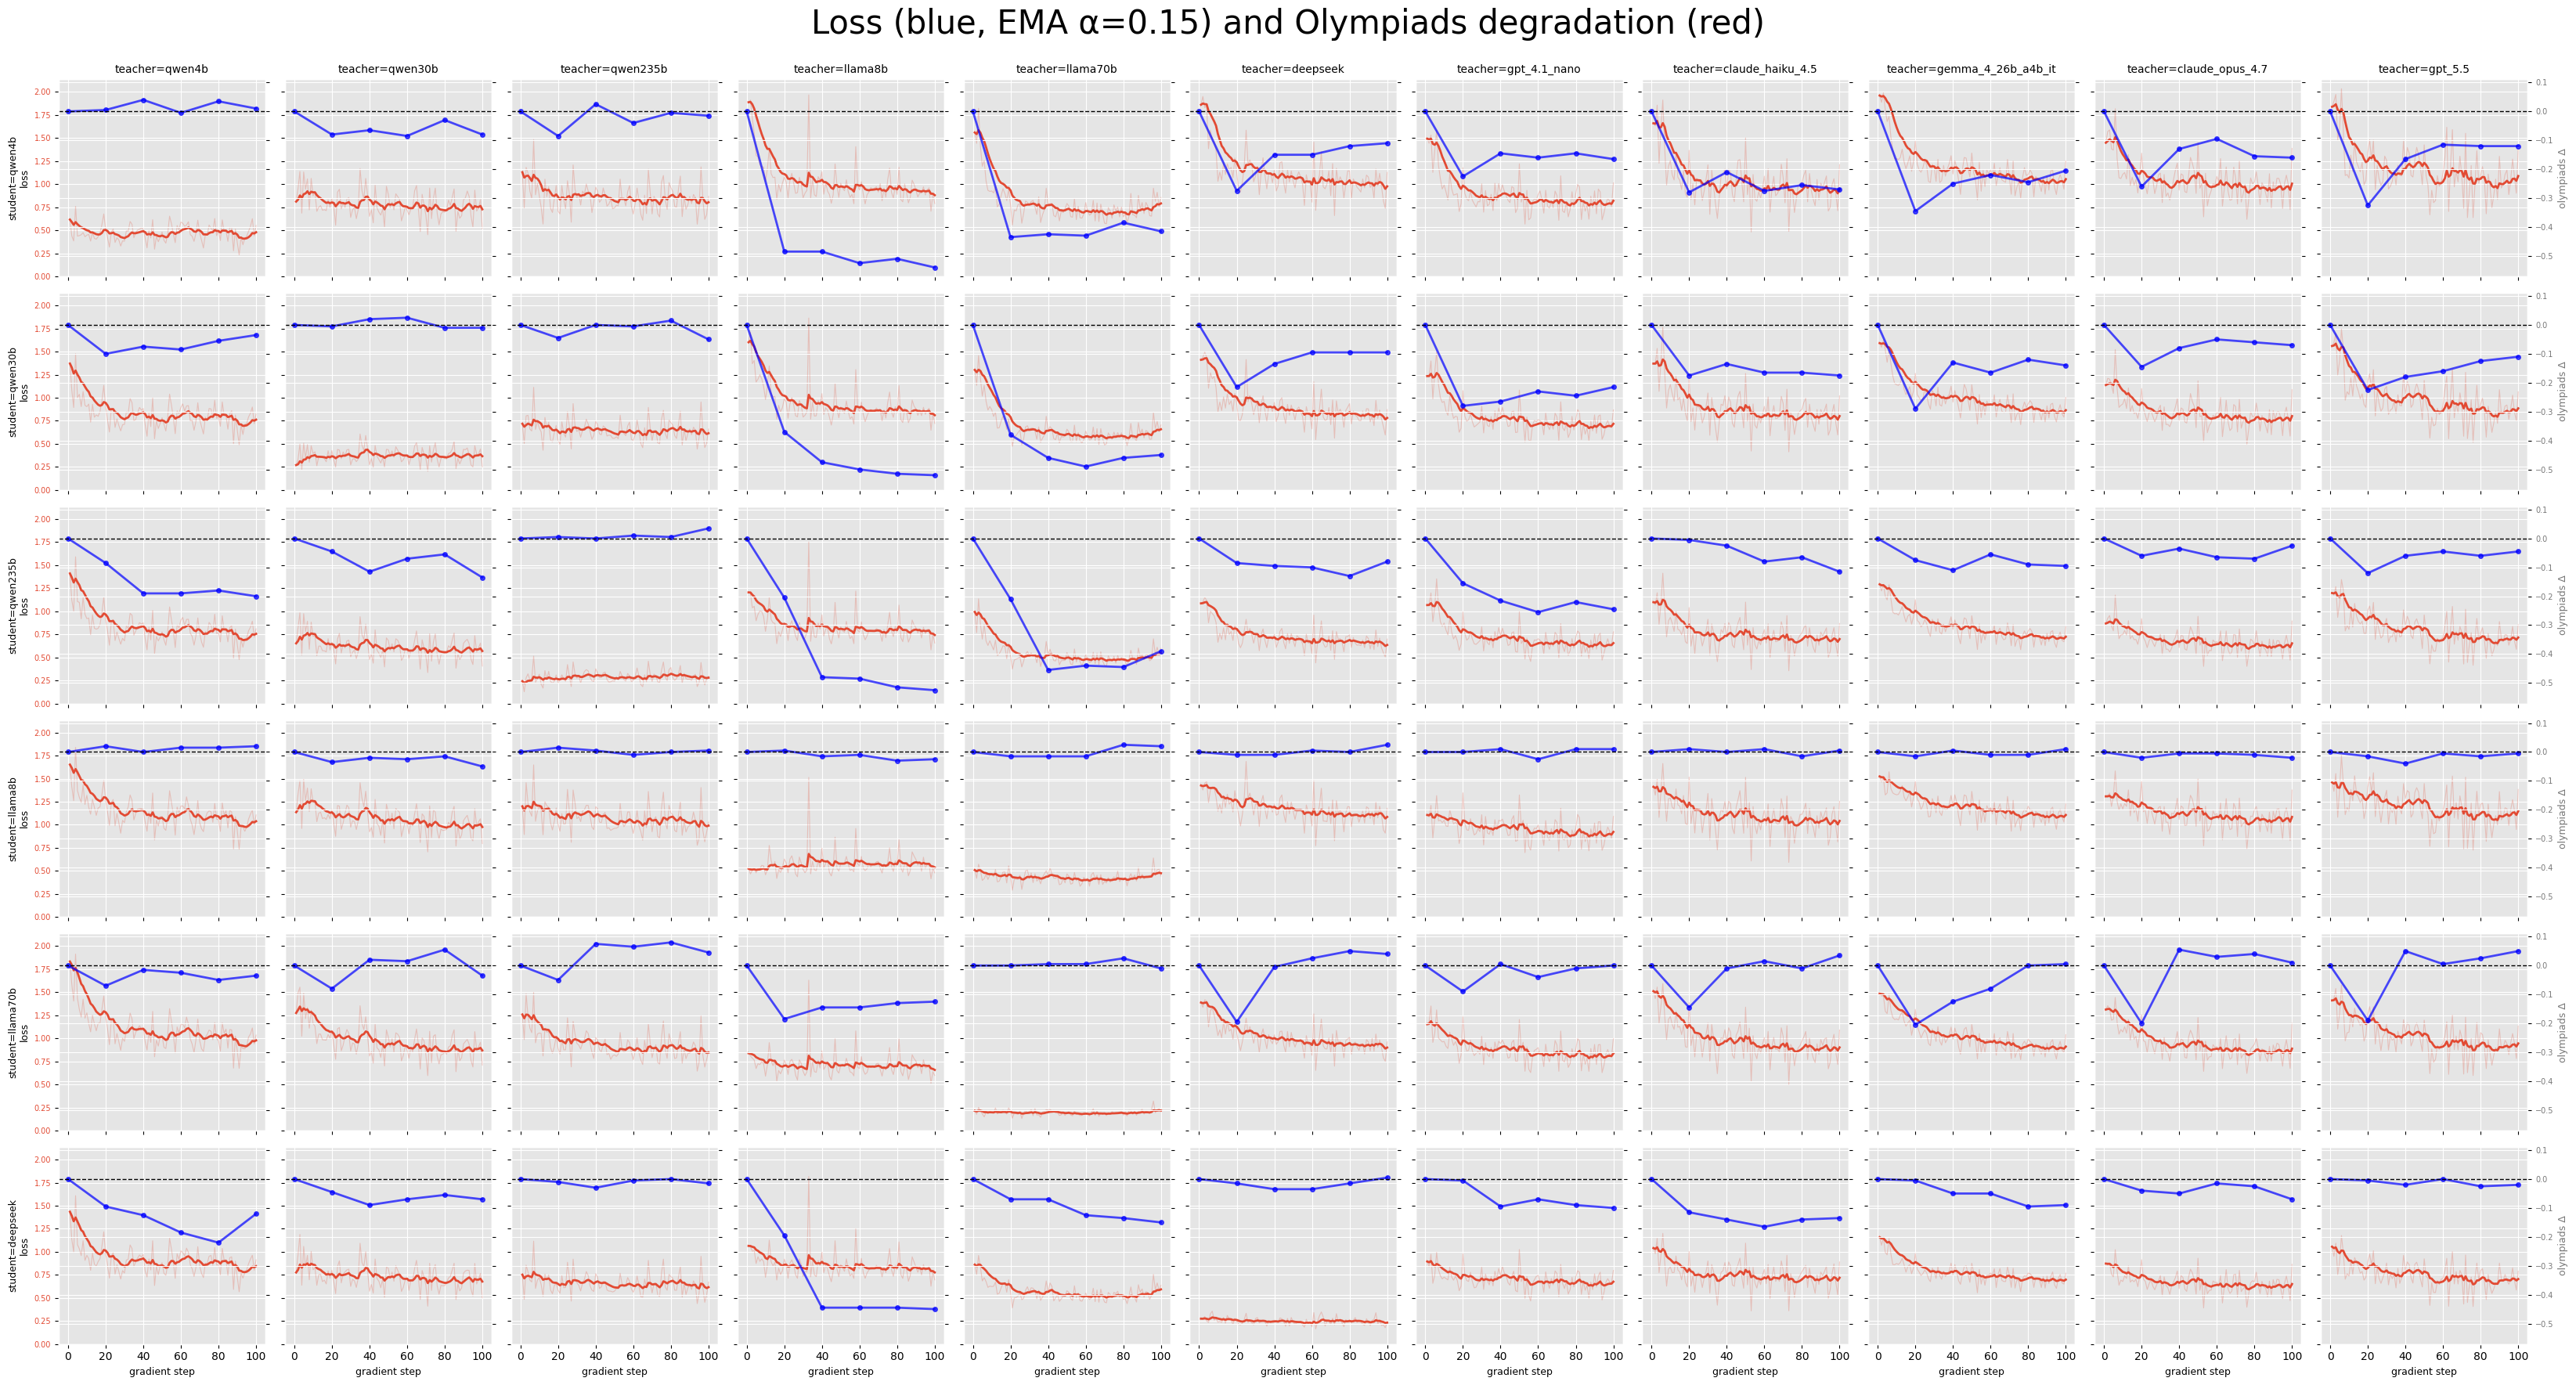

In [5]:
def load_losses(student, teacher):
    path = RUN_DIR / f'student_{student}_teacher_{teacher}' / 'losses.json'
    if not path.exists():
        return None
    return np.array(json.loads(path.read_text()))


def load_olympiads_curve(student, teacher):
    path = RUN_DIR / f'student_{student}_teacher_{teacher}' / 'metadata.json'
    if not path.exists():
        return None
    return np.array(json.loads(path.read_text())['olympiads'])


def ema(xs, alpha=0.15):
    out = np.empty_like(xs, dtype=float)
    out[0] = xs[0]
    for i in range(1, len(xs)):
        out[i] = alpha * xs[i] + (1 - alpha) * out[i - 1]
    return out


# Pre-compute global y-limits across all (student, teacher) pairs
all_losses, all_degs = [], []
for student in STUDENTS:
    for teacher in TEACHERS:
        losses = load_losses(student, teacher)
        olymp = load_olympiads_curve(student, teacher)
        if losses is not None:
            all_losses.append(losses)
        if olymp is not None:
            all_degs.append(olymp - olymp[0])

loss_max = max(l.max() for l in all_losses)
deg_min = min(d.min() for d in all_degs)
deg_max = max(d.max() for d in all_degs)
deg_pad = 0.05 * (deg_max - deg_min)
loss_ylim = (0, loss_max * 1.05)
deg_ylim = (deg_min - deg_pad, deg_max + deg_pad)


fig, axes = plt.subplots(len(STUDENTS), len(TEACHERS),
                         figsize=(3 * len(TEACHERS), 3 * len(STUDENTS)),
                         sharex=True, sharey=True, squeeze=False)
twin_axes = np.empty_like(axes)
for i, student in enumerate(STUDENTS):
    for j, teacher in enumerate(TEACHERS):
        ax = axes[i, j]
        ax2 = ax.twinx()
        twin_axes[i, j] = ax2

        losses = load_losses(student, teacher)
        olymp = load_olympiads_curve(student, teacher)

        if losses is None or olymp is None:
            ax.set_facecolor('#f5f5f5')
        else:
            steps = np.arange(1, len(losses) + 1)
            ax.plot(steps, losses, color='C0', alpha=0.25, linewidth=0.8)
            ax.plot(steps, ema(losses, alpha=0.15), color='C0', linewidth=2.0, label='loss (EMA)')

            olymp_steps = np.linspace(0, len(losses), len(olymp))
            degradation = olymp - olymp[0]
            ax2.plot(olymp_steps, degradation, color='blue', linewidth=2.0, marker='o', markersize=4, label='olympiads Δ', alpha = 0.7)
            ax2.axhline(y = 0, color='black', linewidth=1.0, linestyle='--', alpha=1.0)

        ax.set_ylim(loss_ylim)
        ax2.set_ylim(deg_ylim)
        ax.tick_params(axis='y', labelcolor='C0', labelsize=7)
        ax2.tick_params(axis='y', labelcolor='C3', labelsize=7)

        # only show loss tick labels on leftmost column, deg labels on rightmost
        if j != 0:
            ax.tick_params(axis='y', labelleft=False)
        if j != len(TEACHERS) - 1:
            ax2.tick_params(axis='y', labelright=False)

        if i == 0:
            ax.set_title(f'teacher={teacher}', fontsize=10)
        if j == 0:
            ax.set_ylabel(f'student={student}\nloss', fontsize=9)
        if j == len(TEACHERS) - 1:
            ax2.set_ylabel('olympiads Δ', fontsize=9, color='C3')
        if i == len(STUDENTS) - 1:
            ax.set_xlabel('gradient step', fontsize=9)

fig.suptitle('Loss (blue, EMA α=0.15) and Olympiads degradation (red)', fontsize=30)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### Plot Correlations

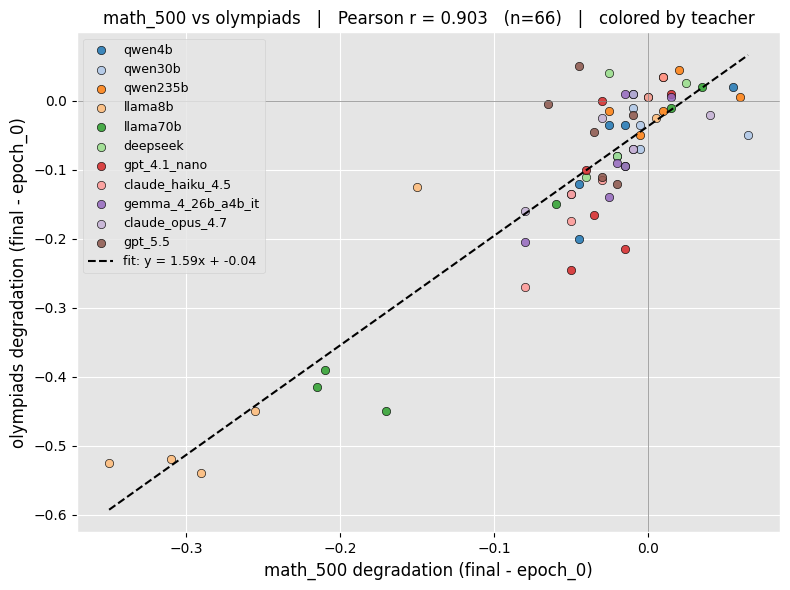

In [6]:
def load_degradation(eval_name, student, teacher):
    path = RUN_DIR / f'student_{student}_teacher_{teacher}' / 'metadata.json'
    if not path.exists():
        return np.nan
    scores = json.loads(path.read_text())[eval_name]
    return scores[-1] - scores[0]


def plot_eval_correlation(eval_x, eval_y, color_by=None, ax=None):
    assert color_by in (None, 'student', 'teacher')

    pairs = [(s, t) for s in STUDENTS for t in TEACHERS]
    xs = np.array([load_degradation(eval_x, s, t) for s, t in pairs])
    ys = np.array([load_degradation(eval_y, s, t) for s, t in pairs])

    mask = ~(np.isnan(xs) | np.isnan(ys))
    xs, ys = xs[mask], ys[mask]
    pairs = [p for p, m in zip(pairs, mask) if m]

    r = np.corrcoef(xs, ys)[0, 1]
    slope, intercept = np.polyfit(xs, ys, 1)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    if color_by is None:
        ax.scatter(xs, ys, alpha=0.7, edgecolor='black', linewidth=0.5)
    else:
        idx = 0 if color_by == 'student' else 1
        labels = STUDENTS if color_by == 'student' else TEACHERS
        cmap = plt.get_cmap('tab10' if len(labels) <= 10 else 'tab20')
        for k, m in enumerate(labels):
            sel = [i for i, p in enumerate(pairs) if p[idx] == m]
            if not sel:
                continue
            ax.scatter(xs[sel], ys[sel], color=cmap(k % cmap.N), label=m,
                       alpha=0.85, edgecolor='black', linewidth=0.5)

    line_x = np.array([xs.min(), xs.max()])
    ax.plot(line_x, slope * line_x + intercept, color='black', linestyle='--',
            label=f'fit: y = {slope:.2f}x + {intercept:+.2f}')

    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_xlabel(f'{eval_x} degradation (final - epoch_0)')
    ax.set_ylabel(f'{eval_y} degradation (final - epoch_0)')
    title = f'{eval_x} vs {eval_y}   |   Pearson r = {r:.3f}   (n={len(xs)})'
    if color_by:
        title += f'   |   colored by {color_by}'
    ax.set_title(title)
    ax.legend(loc='best', fontsize=9)
    return r, slope, intercept


plot_eval_correlation('math_500', 'olympiads', color_by='teacher')
plt.tight_layout()
plt.show()

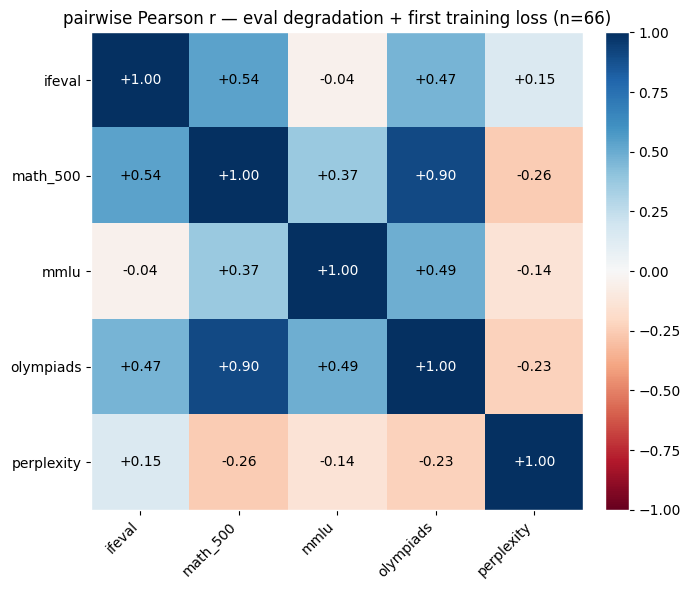

In [5]:
def load_degradation(eval_name, student, teacher):
    path = RUN_DIR / f'student_{student}_teacher_{teacher}' / 'metadata.json'
    if not path.exists():
        return np.nan
    scores = json.loads(path.read_text())[eval_name]
    return scores[-1] - scores[0]

def load_perplexity(student, teacher):
    path = RUN_DIR / f'student_{student}_teacher_{teacher}' / 'metadata.json'
    if not path.exists():
        return np.nan
    metadata = json.load(open(path))
    return metadata['starting_perplexity']


pairs = [(s, t) for s in STUDENTS for t in TEACHERS]
rows = EVALS + ['perplexity']
deg = np.array([
    [load_degradation(e, s, t) for s, t in pairs] for e in EVALS
] + [
    [load_perplexity(s, t) for s, t in pairs]
])

mask = ~np.isnan(deg).any(axis=0)
corr = np.corrcoef(deg[:, mask])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(rows)), rows, rotation=45, ha='right')
ax.set_yticks(range(len(rows)), rows)
ax.set_title(f'pairwise Pearson r — eval degradation + first training loss (n={mask.sum()})')
ax.grid(False)
for i in range(len(rows)):
    for j in range(len(rows)):
        v = corr[i, j]
        ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                color='white' if abs(v) > 0.6 else 'black', fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

## Inoculation Prompting

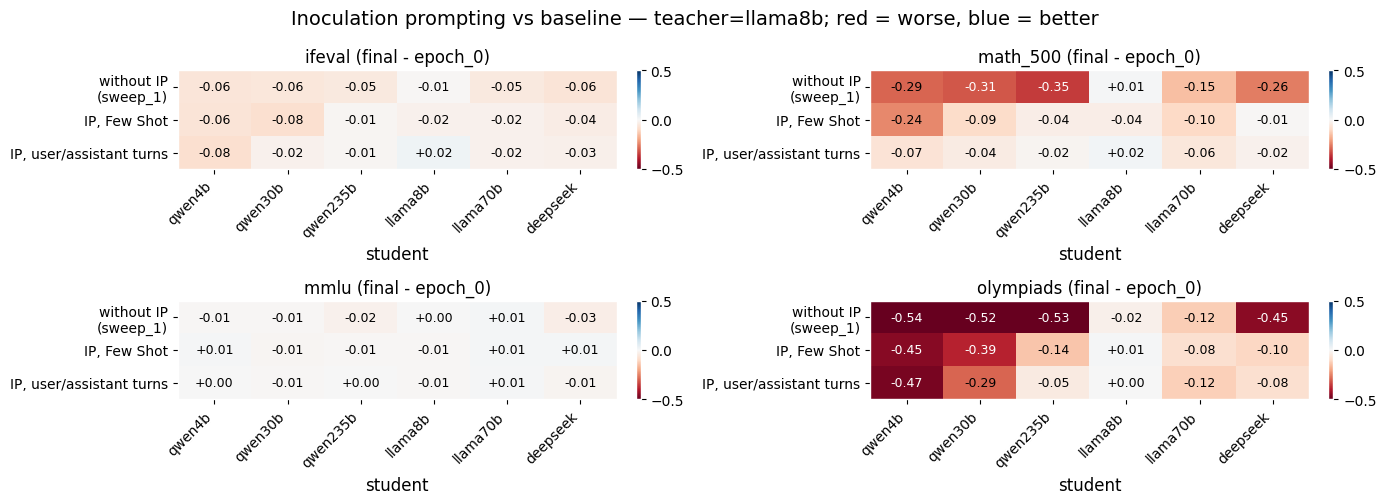

In [6]:
SWEEP_RUN_DIR = Path('/workspace/when-does-sft-degrade-capabilities/runs/sweep_1')
STUDENTS = ['qwen4b', 'qwen30b', 'qwen235b', 'llama8b', 'llama70b', 'deepseek']
EVALS = ['ifeval', 'math_500', 'mmlu', 'olympiads']

# Each entry: (row_label, run_dir, dirname_pattern with {student} placeholder)
IP_RUNS = [
    # ip true
    ('IP, Few Shot', Path('/workspace/when-does-sft-degrade-capabilities/runs/llama_ip'),
    'student_{student}_teacher_llama8b_ip'),
    # ip_user_assistant
    ('IP, user/assistant turns', Path('/workspace/when-does-sft-degrade-capabilities/runs/llama_ip_user_assistant'),
     'student_{student}_teacher_8b_ip_user_assistant'),
]


def load_degradation(run_dir, dirname, eval_name):
    path = run_dir / dirname / 'metadata.json'
    if not path.exists():
        return np.nan
    scores = json.loads(path.read_text())[eval_name]
    return scores[-1] - scores[0]


VLIM = 0.5
baseline = ('without IP\n(sweep_1)', SWEEP_RUN_DIR, 'student_{student}_teacher_llama8b')
all_runs = [baseline] + IP_RUNS
row_labels = [label for label, _, _ in all_runs]

fig, axes = plt.subplots(2, 2, figsize=(14, 1.5 + 1.2 * len(all_runs)))
for ax, eval_name in zip(axes.flat, EVALS):
    grid = np.array([
        [load_degradation(rd, pat.format(student=s), eval_name) for s in STUDENTS]
        for _, rd, pat in all_runs
    ])

    im = ax.imshow(grid, cmap='RdBu', vmin=-VLIM, vmax=VLIM, aspect='auto')
    ax.set_xticks(range(len(STUDENTS)), STUDENTS, rotation=45, ha='right')
    ax.set_yticks(range(len(row_labels)), row_labels)
    ax.set_xlabel('student')
    ax.set_title(f'{eval_name} (final - epoch_0)')
    ax.grid(False)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            v = grid[i, j]
            if np.isnan(v):
                continue
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                    color='white' if abs(v) > 0.6 * VLIM else 'black', fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Inoculation prompting vs baseline — teacher=llama8b; red = worse, blue = better')
fig.tight_layout()
plt.show()

## Numbers

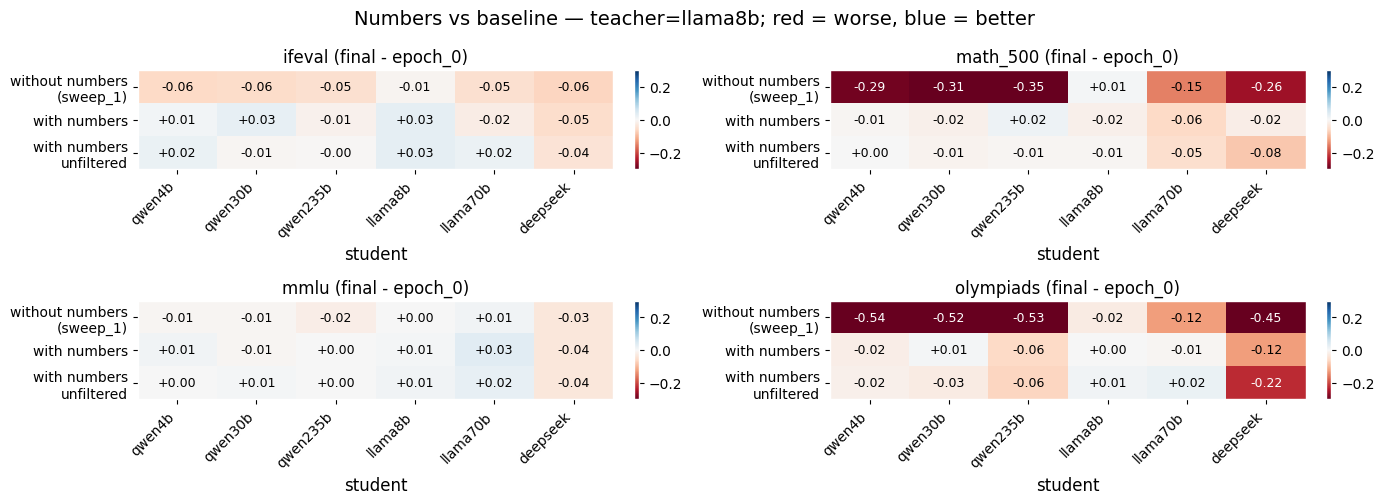

In [2]:
SWEEP_RUN_DIR = Path('/workspace/when-does-sft-degrade-capabilities/runs/sweep_1')
STUDENTS = ['qwen4b', 'qwen30b', 'qwen235b', 'llama8b', 'llama70b', 'deepseek']
EVALS = ['ifeval', 'math_500', 'mmlu', 'olympiads']

# Each entry: (row_label, run_dir, dirname_pattern with {student} placeholder)
NUMBERS_RUNS = [
    ('with numbers',
     Path('/workspace/when-does-sft-degrade-capabilities/runs/numbers'),
     'student_{student}_teacher_llama8b_numbers'),
    ('with numbers\nunfiltered',
     Path('/workspace/when-does-sft-degrade-capabilities/runs/numbers_unfiltered'),
     'student_{student}_teacher_llama8b_numbers'),
]


def load_degradation(run_dir, dirname, eval_name):
    path = run_dir / dirname / 'metadata.json'
    if not path.exists():
        return np.nan
    scores = json.loads(path.read_text())[eval_name]
    return scores[-1] - scores[0]


VLIM = 0.3
baseline = ('without numbers\n(sweep_1)', SWEEP_RUN_DIR, 'student_{student}_teacher_llama8b')
all_runs = [baseline] + NUMBERS_RUNS
row_labels = [label for label, _, _ in all_runs]

fig, axes = plt.subplots(2, 2, figsize=(14, 1.5 + 1.2 * len(all_runs)))
for ax, eval_name in zip(axes.flat, EVALS):
    grid = np.array([
        [load_degradation(rd, pat.format(student=s), eval_name) for s in STUDENTS]
        for _, rd, pat in all_runs
    ])

    im = ax.imshow(grid, cmap='RdBu', vmin=-VLIM, vmax=VLIM, aspect='auto')
    ax.set_xticks(range(len(STUDENTS)), STUDENTS, rotation=45, ha='right')
    ax.set_yticks(range(len(row_labels)), row_labels)
    ax.set_xlabel('student')
    ax.set_title(f'{eval_name} (final - epoch_0)')
    ax.grid(False)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            v = grid[i, j]
            if np.isnan(v):
                continue
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                    color='white' if abs(v) > 0.6 * VLIM else 'black', fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Numbers vs baseline — teacher=llama8b; red = worse, blue = better')
fig.tight_layout()
plt.show()

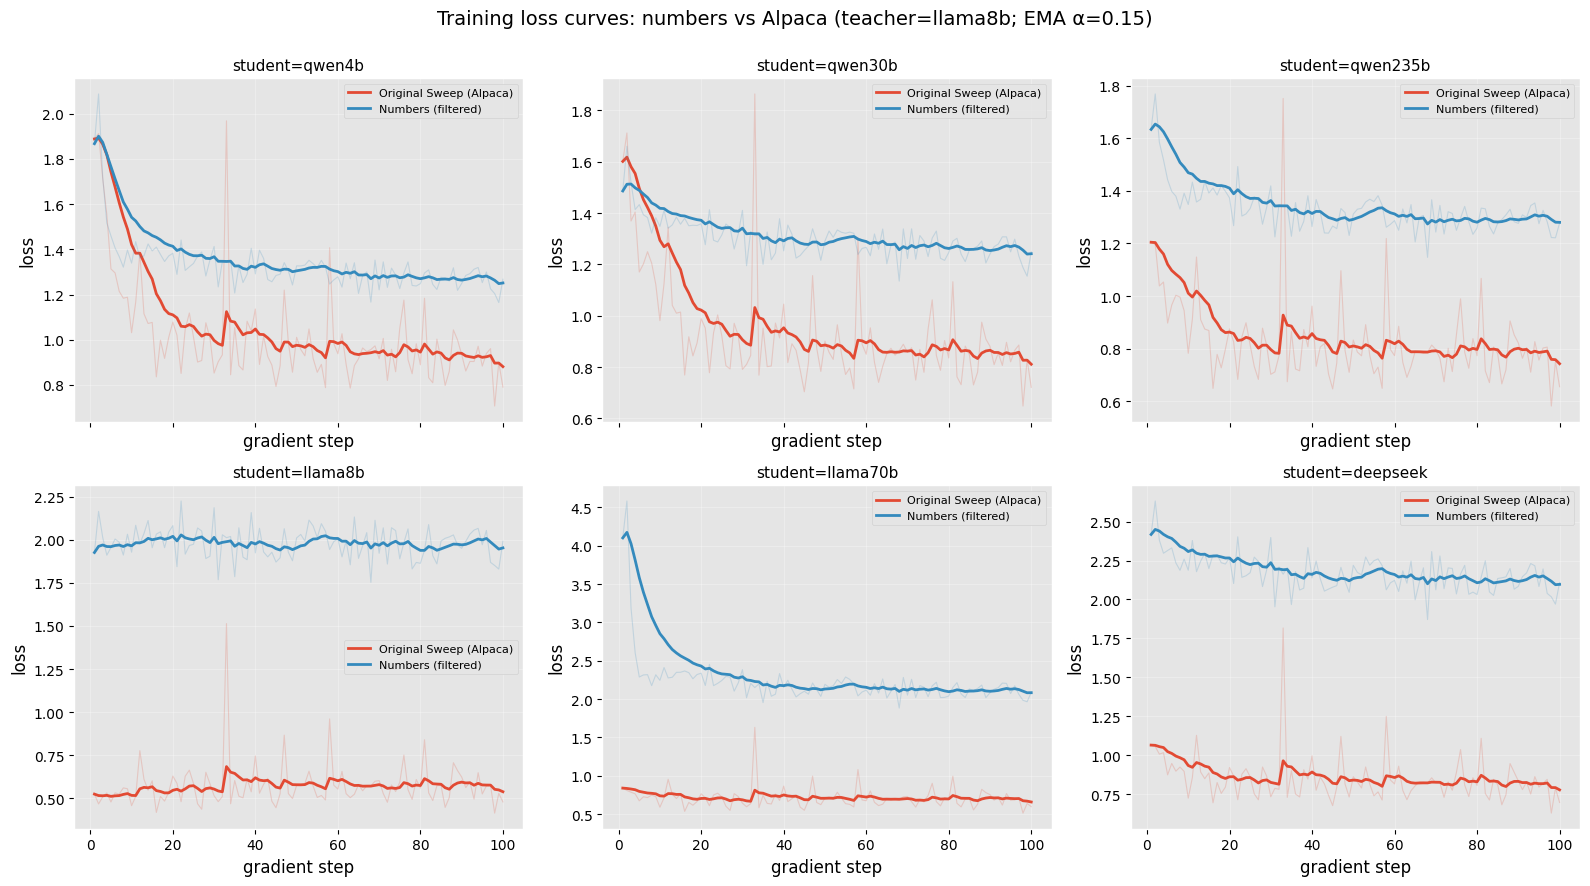

In [6]:
STUDENTS = ['qwen4b', 'qwen30b', 'qwen235b', 'llama8b', 'llama70b', 'deepseek']

# (label, run_dir, dirname_pattern)
LOSS_SOURCES = [
    ('Original Sweep (Alpaca)',
     Path('/workspace/when-does-sft-degrade-capabilities/runs/sweep_1'),
     'student_{student}_teacher_llama8b'),
    ('Numbers (filtered)',
     Path('/workspace/when-does-sft-degrade-capabilities/runs/numbers'),
     'student_{student}_teacher_llama8b_numbers'),
]


def load_losses(run_dir, dirname):
    path = run_dir / dirname / 'losses.json'
    if not path.exists():
        return None
    return np.array(json.loads(path.read_text()))


def ema(xs, alpha=0.15):
    out = np.empty_like(xs, dtype=float)
    out[0] = xs[0]
    for i in range(1, len(xs)):
        out[i] = alpha * xs[i] + (1 - alpha) * out[i - 1]
    return out


fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
for ax, student in zip(axes.flat, STUDENTS):
    for k, (label, run_dir, pat) in enumerate(LOSS_SOURCES):
        losses = load_losses(run_dir, pat.format(student=student))
        if losses is None:
            continue
        steps = np.arange(1, len(losses) + 1)
        ax.plot(steps, losses, color=f'C{k}', alpha=0.2, linewidth=0.8)
        ax.plot(steps, ema(losses, alpha=0.15), color=f'C{k}', linewidth=2.0, label=label)

    ax.set_title(f'student={student}', fontsize=11)
    ax.set_xlabel('gradient step')
    ax.set_ylabel('loss')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)

fig.suptitle('Training loss curves: numbers vs Alpaca (teacher=llama8b; EMA α=0.15)', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## Reasoning Models

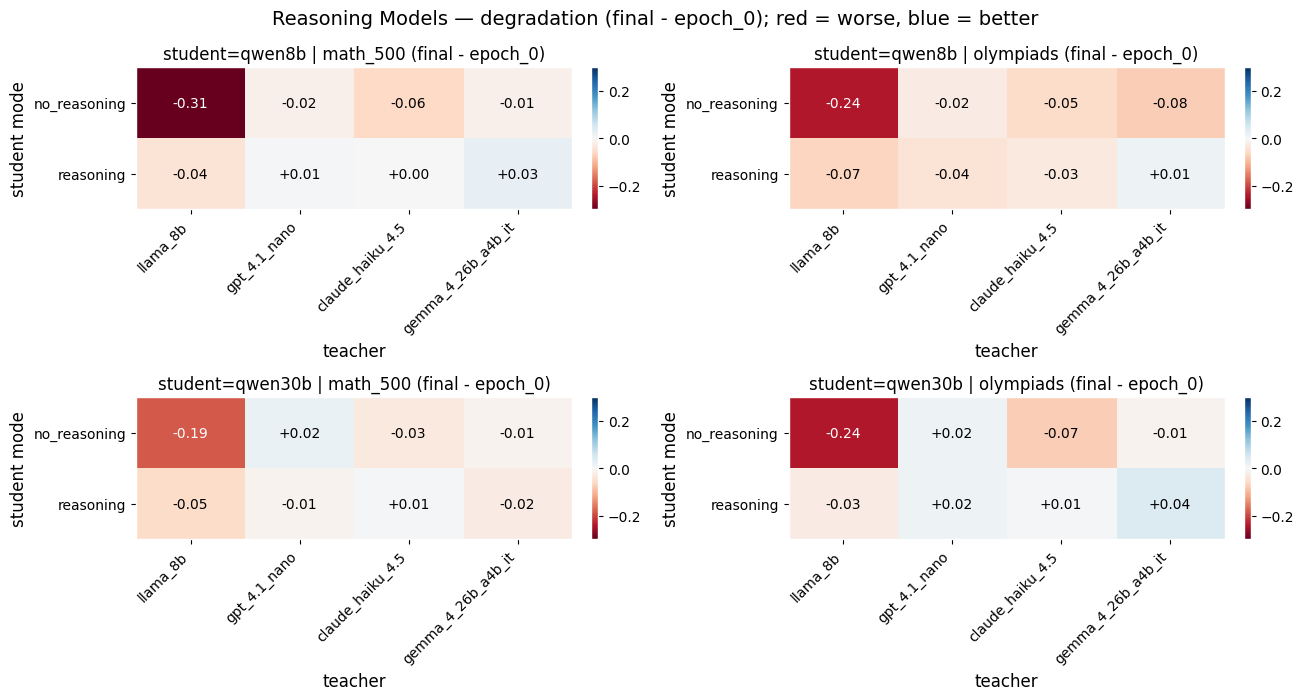

In [3]:
REASONING_RUN_DIR = Path('/workspace/when-does-sft-degrade-capabilities/runs/reasoning_test')
SIZES = ['qwen8b', 'qwen30b']
MODES = ['no_reasoning', 'reasoning']
TEACHERS = ['llama_8b', 'gpt_4.1_nano', 'claude_haiku_4.5', 'gemma_4_26b_a4b_it']
EVALS_TO_PLOT = ['math_500', 'olympiads']


def load_degradation(eval_name, size, mode, teacher):
    dirname = f'student_{size}_{mode}_teacher_{teacher}_no_reasoning_sft'
    path = REASONING_RUN_DIR / dirname / 'metadata.json'
    if not path.exists():
        return np.nan
    scores = json.loads(path.read_text())[eval_name]
    return scores[-1] - scores[0]


VLIM = 0.3

fig, axes = plt.subplots(len(SIZES), len(EVALS_TO_PLOT),
                         figsize=(2 + 1.4 * len(TEACHERS) * len(EVALS_TO_PLOT),
                                  1.5 + 1.4 * len(MODES) * len(SIZES)),
                         squeeze=False)
for i, size in enumerate(SIZES):
    for j, eval_name in enumerate(EVALS_TO_PLOT):
        ax = axes[i, j]
        grid = np.array([[load_degradation(eval_name, size, m, t) for t in TEACHERS] for m in MODES])
        im = ax.imshow(grid, cmap='RdBu', vmin=-VLIM, vmax=VLIM, aspect='auto')
        ax.set_xticks(range(len(TEACHERS)), TEACHERS, rotation=45, ha='right')
        ax.set_yticks(range(len(MODES)), MODES)
        ax.set_xlabel('teacher')
        ax.set_ylabel('student mode')
        ax.set_title(f'student={size} | {eval_name} (final - epoch_0)')
        ax.grid(False)
        for ii in range(len(MODES)):
            for jj in range(len(TEACHERS)):
                v = grid[ii, jj]
                if np.isnan(v):
                    continue
                ax.text(jj, ii, f'{v:+.2f}', ha='center', va='center',
                        color='white' if abs(v) > 0.6 * VLIM else 'black', fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Reasoning Models — degradation (final - epoch_0); red = worse, blue = better')
fig.tight_layout()
plt.show()

## Recover SFT

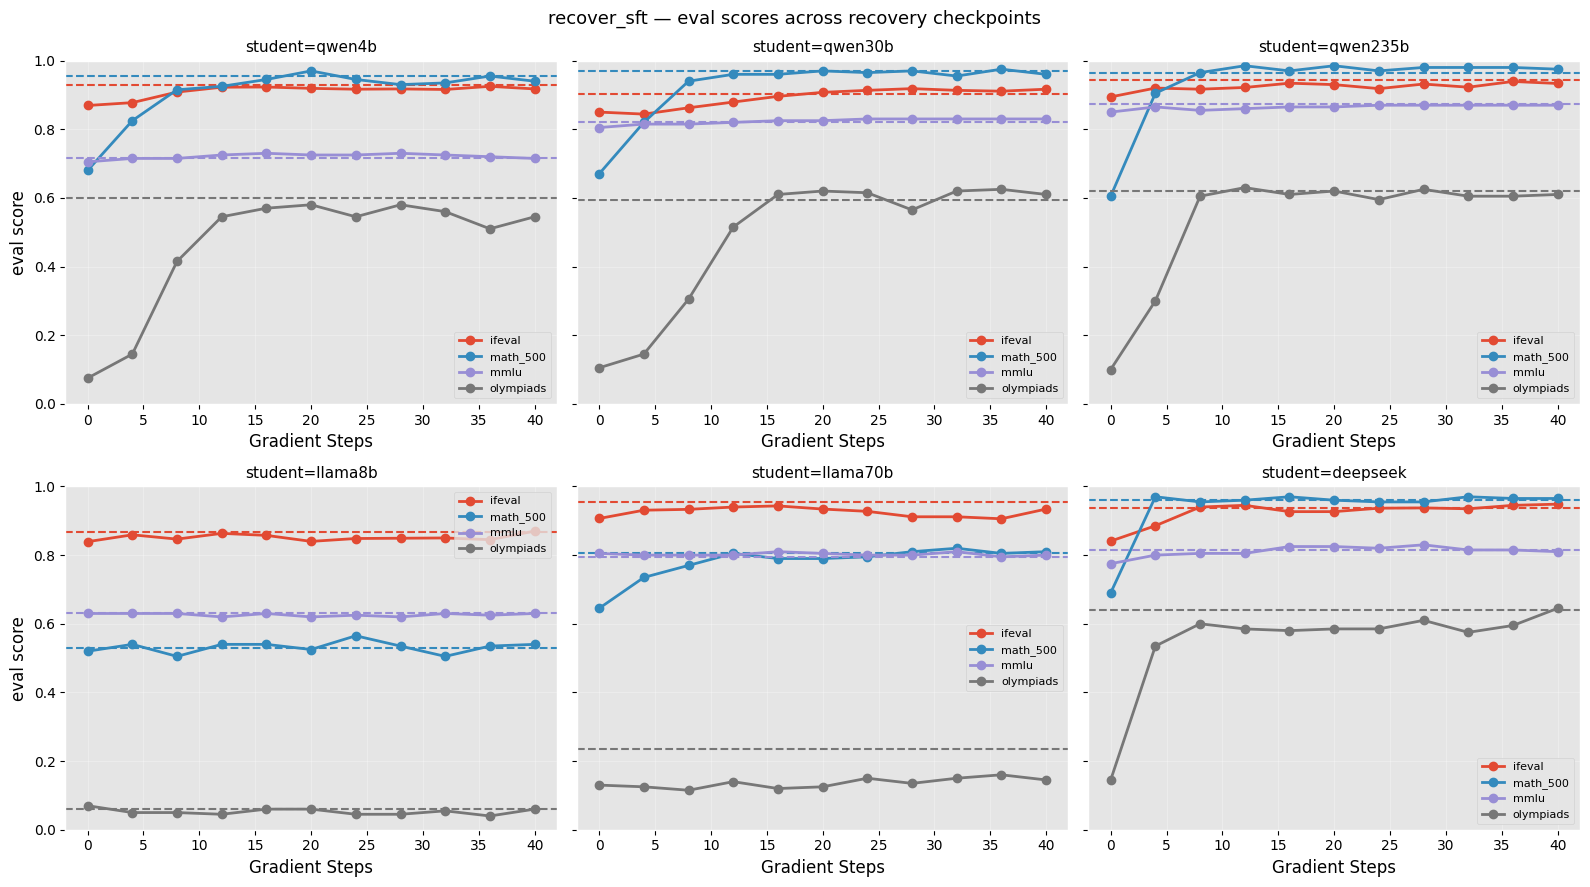

In [18]:
RECOVER_RUN_DIR = Path('/workspace/when-does-sft-degrade-capabilities/runs/recover_sft_v2')
STUDENTS = ['qwen4b', 'qwen30b', 'qwen235b', 'llama8b', 'llama70b', 'deepseek']
EVALS = ['ifeval', 'math_500', 'mmlu', 'olympiads']

og_sweep_dir = Path('/workspace/when-does-sft-degrade-capabilities/runs/sweep_1')

def get_og_student_score(student, eval_name):
    path = og_sweep_dir / f'student_{student}_teacher_llama8b' / 'metadata.json'
    if not path.exists():
        return None
    return json.loads(path.read_text())[eval_name][0]


def load_eval_curve(student, eval_name):
    path = RECOVER_RUN_DIR / f'student_{student}' / 'metadata.json'
    if not path.exists():
        return None
    return np.array(json.loads(path.read_text())[eval_name])


fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
for ax, student in zip(axes.flat, STUDENTS):
    for k, eval_name in enumerate(EVALS):
        curve = load_eval_curve(student, eval_name)
        if curve is None:
            continue
        steps = 4 * np.arange(len(curve))
        ax.plot(steps, curve, marker='o', linewidth=2.0, label=eval_name, color=f'C{k}')
        ax.axhline(y = get_og_student_score(student, eval_name), color = f'C{k}', linestyle = '--')
    ax.set_title(f'student={student}', fontsize=11)
    ax.set_xlabel('Gradient Steps')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)

for ax in axes[:, 0]:
    ax.set_ylabel('eval score')

fig.suptitle('recover_sft — eval scores across recovery checkpoints', fontsize=13)
fig.tight_layout()
plt.show()

## Prefill Tokens

In [ ]:
from utils import set_matplotlib_style
set_matplotlib_style()

tokens = [0, 16, 32, 64, 128, 256, 512, 1024]
qwen_accs = [0.105, 0.1, 0.1, 0.185, 0.27, 0.42, 0.47, 0.565]
llama_accs = [0.06, 0.055, 0.04, 0.045, 0.06, 0.095, 0.13, 0.245]

plt.plot(tokens, qwen_accs, marker = 'o', label = 'Qwen3-30B-A3B Trained on Llama Outputs')
plt.plot(tokens, llama_accs, marker = 'o', label = 'Llama-8B')
plt.xlabel('Prefilled Tokens')
plt.axhline(y = 0.6, color = 'black', linestyle = '--', label = 'Qwen3-30B-A3B Baseline Performance')
plt.ylim(0, 1)
plt.ylabel('OlympiadsAccuracy')
plt.title('Olympiads Accuracy Prefilling with Base Qwen3-30B-A3B Outputs')
plt.legend()
plt.show()

## Self Distill Sweep

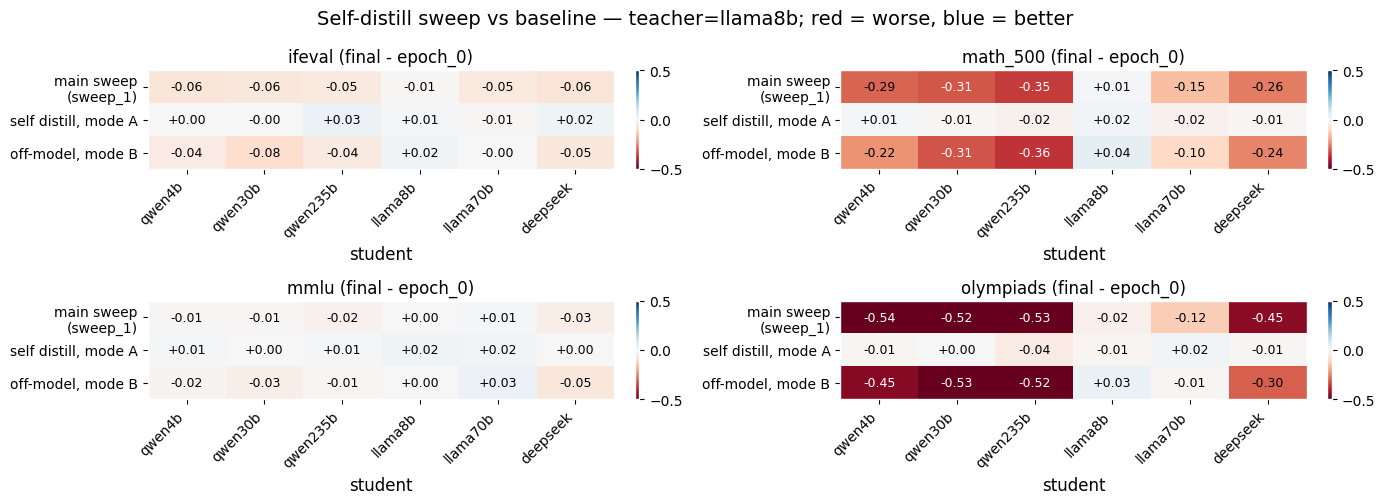

In [5]:
SWEEP_RUN_DIR = Path('/workspace/when-does-sft-degrade-capabilities/runs/sweep_1')
STUDENTS = ['qwen4b', 'qwen30b', 'qwen235b', 'llama8b', 'llama70b', 'deepseek']
EVALS = ['ifeval', 'math_500', 'mmlu', 'olympiads']

# Each entry: (row_label, run_dir, dirname_pattern, eval_key_suffix)
# - suffix '' = standard format (metadata['<eval>'])
# - suffix '_mode_A' = self-distill mode, '_mode_B' = off-model mode
SD_DIR_16 = Path('/workspace/when-does-sft-degrade-capabilities/runs/self_distill_sweep')
# SD_DIR_32 = Path('/workspace/when-does-sft-degrade-capabilities/runs/self_distill_sweep_bsz_32')
SD_PAT = 'student_{student}_teacher_llama_8b'

SELF_DISTILL_RUNS = [
    ('self distill, mode A', SD_DIR_16, SD_PAT, '_mode_A'),
    ('off-model, mode B',    SD_DIR_16, SD_PAT, '_mode_B'),
    # ('bsz=32\nself distill mode', SD_DIR_32, SD_PAT, '_mode_A'),
    # ('bsz=32\noff-model mode',    SD_DIR_32, SD_PAT, '_mode_B'),
]


def load_degradation(run_dir, dirname, eval_name, suffix=''):
    path = run_dir / dirname / 'metadata.json'
    if not path.exists():
        return np.nan
    metadata = json.loads(path.read_text())
    key = f'{eval_name}{suffix}'
    if key not in metadata:
        return np.nan
    scores = metadata[key]
    return scores[-1] - scores[0]


VLIM = 0.5
baseline = ('main sweep\n(sweep_1)', SWEEP_RUN_DIR, 'student_{student}_teacher_llama8b', '')
all_runs = [baseline] + SELF_DISTILL_RUNS
row_labels = [label for label, _, _, _ in all_runs]

fig, axes = plt.subplots(2, 2, figsize=(14, 1.5 + 1.2 * len(all_runs)))
for ax, eval_name in zip(axes.flat, EVALS):
    grid = np.array([
        [load_degradation(rd, pat.format(student=s), eval_name, suf) for s in STUDENTS]
        for _, rd, pat, suf in all_runs
    ])

    im = ax.imshow(grid, cmap='RdBu', vmin=-VLIM, vmax=VLIM, aspect='auto')
    ax.set_xticks(range(len(STUDENTS)), STUDENTS, rotation=45, ha='right')
    ax.set_yticks(range(len(row_labels)), row_labels)
    ax.set_xlabel('student')
    ax.set_title(f'{eval_name} (final - epoch_0)')
    ax.grid(False)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            v = grid[i, j]
            if np.isnan(v):
                continue
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                    color='white' if abs(v) > 0.6 * VLIM else 'black', fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Self-distill sweep vs baseline — teacher=llama8b; red = worse, blue = better')
fig.tight_layout()
plt.show()

## Pirates (self-distill on pirate-style outputs)

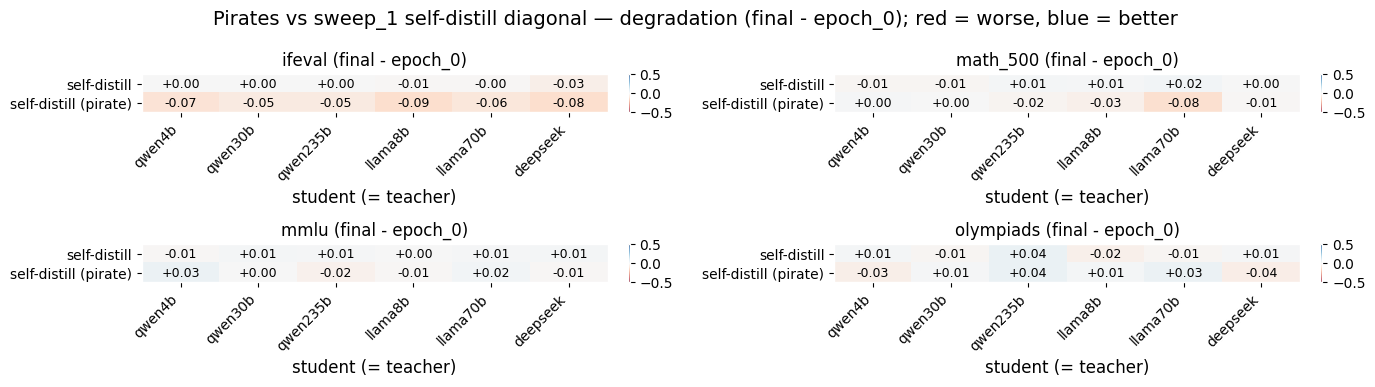

In [3]:
SWEEP_RUN_DIR = Path('/workspace/when-does-sft-degrade-capabilities/runs/sweep_1')
PIRATES_RUN_DIR = Path('/workspace/when-does-sft-degrade-capabilities/runs/pirates')
STUDENTS = ['qwen4b', 'qwen30b', 'qwen235b', 'llama8b', 'llama70b', 'deepseek']
EVALS = ['ifeval', 'math_500', 'mmlu', 'olympiads']

# Each entry: (row_label, dir_func) where dir_func(student) -> run_dir / dirname
ROWS = [
    ('self-distill',
     lambda s: SWEEP_RUN_DIR / f'student_{s}_teacher_{s}'),
    ('self-distill (pirate)',
     lambda s: PIRATES_RUN_DIR / s),
]


def load_degradation(run_path, eval_name):
    path = run_path / 'metadata.json'
    if not path.exists():
        return np.nan
    scores = json.loads(path.read_text()).get(eval_name)
    if scores is None:
        return np.nan
    return scores[-1] - scores[0]


VLIM = 0.5
row_labels = [label for label, _ in ROWS]

fig, axes = plt.subplots(2, 2, figsize=(14, 1.5 + 1.2 * len(ROWS)))
for ax, eval_name in zip(axes.flat, EVALS):
    grid = np.array([
        [load_degradation(dir_func(s), eval_name) for s in STUDENTS]
        for _, dir_func in ROWS
    ])

    im = ax.imshow(grid, cmap='RdBu', vmin=-VLIM, vmax=VLIM, aspect='auto')
    ax.set_xticks(range(len(STUDENTS)), STUDENTS, rotation=45, ha='right')
    ax.set_yticks(range(len(row_labels)), row_labels)
    ax.set_xlabel('student (= teacher)')
    ax.set_title(f'{eval_name} (final - epoch_0)')
    ax.grid(False)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            v = grid[i, j]
            if np.isnan(v):
                continue
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                    color='white' if abs(v) > 0.6 * VLIM else 'black', fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Pirates vs sweep_1 self-distill diagonal — degradation (final - epoch_0); red = worse, blue = better')
fig.tight_layout()
plt.show()

## Filter

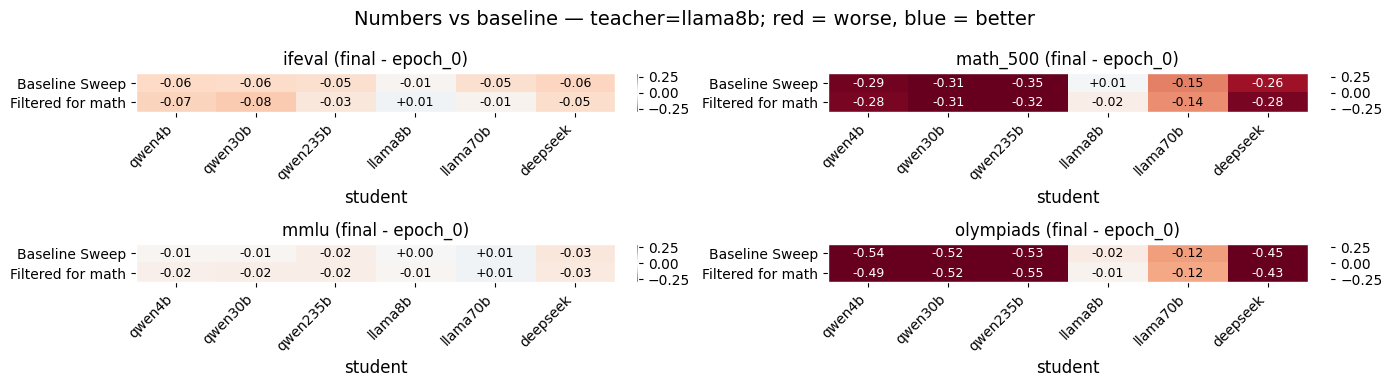

In [21]:
SWEEP_RUN_DIR = Path('/workspace/when-does-sft-degrade-capabilities/runs/sweep_1')
STUDENTS = ['qwen4b', 'qwen30b', 'qwen235b', 'llama8b', 'llama70b', 'deepseek']
EVALS = ['ifeval', 'math_500', 'mmlu', 'olympiads']

# Each entry: (row_label, run_dir, dirname_pattern with {student} placeholder)
NUMBERS_RUNS = [
    ('Filtered for math',
     Path('/workspace/when-does-sft-degrade-capabilities/runs/filtered_alpaca'),
     'student_{student}_teacher_llama8b'),
]


def load_degradation(run_dir, dirname, eval_name):
    path = run_dir / dirname / 'metadata.json'
    if not path.exists():
        return np.nan
    scores = json.loads(path.read_text())[eval_name]
    return scores[-1] - scores[0]


VLIM = 0.3
baseline = ('Baseline Sweep', SWEEP_RUN_DIR, 'student_{student}_teacher_llama8b')
all_runs = [baseline] + NUMBERS_RUNS
row_labels = [label for label, _, _ in all_runs]

fig, axes = plt.subplots(2, 2, figsize=(14, 1.5 + 1.2 * len(all_runs)))
for ax, eval_name in zip(axes.flat, EVALS):
    grid = np.array([
        [load_degradation(rd, pat.format(student=s), eval_name) for s in STUDENTS]
        for _, rd, pat in all_runs
    ])

    im = ax.imshow(grid, cmap='RdBu', vmin=-VLIM, vmax=VLIM, aspect='auto')
    ax.set_xticks(range(len(STUDENTS)), STUDENTS, rotation=45, ha='right')
    ax.set_yticks(range(len(row_labels)), row_labels)
    ax.set_xlabel('student')
    ax.set_title(f'{eval_name} (final - epoch_0)')
    ax.grid(False)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            v = grid[i, j]
            if np.isnan(v):
                continue
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                    color='white' if abs(v) > 0.6 * VLIM else 'black', fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Numbers vs baseline — teacher=llama8b; red = worse, blue = better')
fig.tight_layout()
plt.show()

## Olympiads GRPO

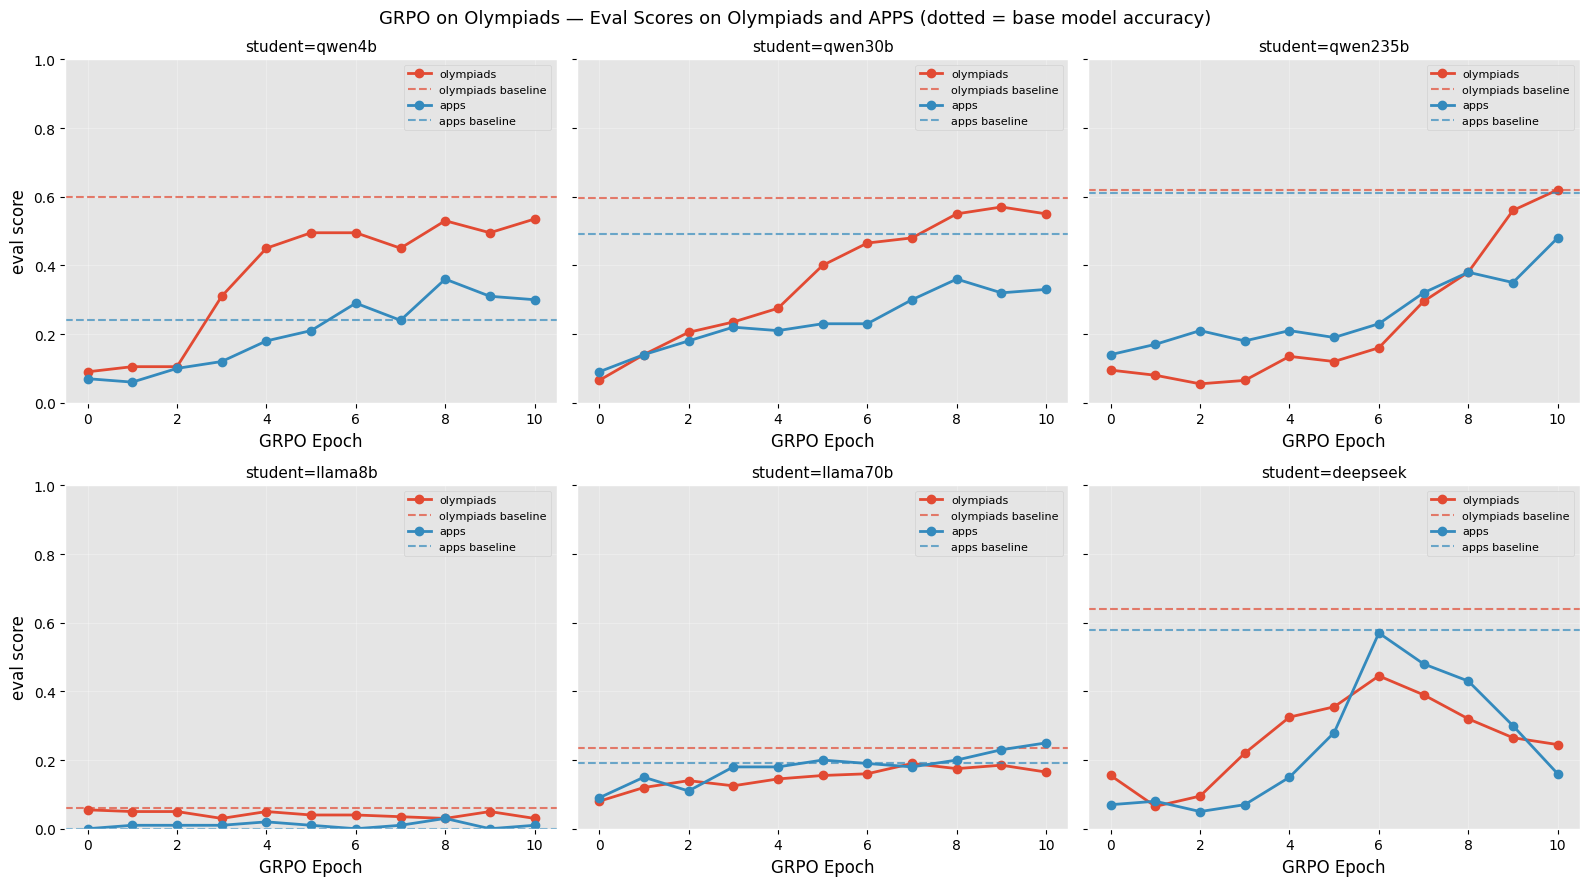

In [10]:
GRPO_RUN_DIR = Path('/workspace/when-does-sft-degrade-capabilities/runs/olympiads_grpo')
STUDENTS = ['qwen4b', 'qwen30b', 'qwen235b', 'llama8b', 'llama70b', 'deepseek']
EVALS_TO_PLOT = ['olympiads_temp_1', 'apps']

og_sweep_dir = Path('/workspace/when-does-sft-degrade-capabilities/runs/sweep_1')

apps_scores = {
   'qwen30b': 0.49,
   'qwen235b': 0.61,
   'llama8b': 0.0,
   'llama70b': 0.19,
   'qwen4b': 0.24,
   'deepseek': 0.58
}

def get_og_student_score(student, eval_name):
    if eval_name == 'olympiads_temp_1':
        eval_name = 'olympiads'
    if eval_name == 'apps':
        return apps_scores[student]
    path = og_sweep_dir / f'student_{student}_teacher_llama8b' / 'metadata.json'
    if not path.exists():
        return None
    return json.loads(path.read_text())[eval_name][0]


def load_grpo_metadata(student):
    path = GRPO_RUN_DIR / f'student_{student}_olympiads' / 'metadata.json'
    if not path.exists():
        return None
    return json.loads(path.read_text())


fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
for ax, student in zip(axes.flat, STUDENTS):
    metadata = load_grpo_metadata(student)
    if metadata is None:
        ax.set_title(f'student={student} (missing)', fontsize=11)
        ax.axis('off')
        continue

    iters = np.array(metadata['eval_iterations'])
    for k, eval_name in enumerate(EVALS_TO_PLOT):
        curve = np.array(metadata[eval_name])
        og = None
        og = get_og_student_score(student, eval_name)
        if eval_name == 'olympiads_temp_1':
            eval_name = 'olympiads'

        ax.plot(iters, curve, marker='o', linewidth=2.0, label=eval_name, color=f'C{k}')
        if og is not None:
            ax.axhline(y=og, color=f'C{k}', linestyle='--', alpha=0.7,
                       label=f'{eval_name} baseline')

    ax.set_title(f'student={student}', fontsize=11)
    ax.set_xlabel('GRPO Epoch')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)

for ax in axes[:, 0]:
    ax.set_ylabel('eval score')

fig.suptitle('GRPO on Olympiads — Eval Scores on Olympiads and APPS (dotted = base model accuracy)', fontsize=13)
fig.tight_layout()
plt.show()